# 01 - Ingesta, calidad y definición del objetivo

Este notebook valida la primera decisión importante del TFM: la unidad de observación es una **persona implicada en un accidente**, no el accidente completo (en un accidente están implicadas varias personas). Construimos `lesion_grave` con los códigos oficiales 03 y 04 que se corresponden con hospitalización de más de 24h o fallecimiento.

Todavía no entrenamos modelos. Antes debemos comprobar el esquema, la calidad de los datos, el volumen y el desbalance del objetivo.

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve() #me traigo la ruta
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from tfm_accidentes.config import PROCESSED_DATA_DIR, RAW_DATA_DIR
from tfm_accidentes.data import build_analysis_table, build_quality_report, load_raw_files

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
PROJECT_ROOT




WindowsPath('C:/Users/larre/OneDrive/Documentos/codigo tf accidentes')

## 1. Descarga reproducible

La siguiente celda consulta la API del Portal de Datos Abiertos de Madrid, localiza los recursos CSV de 2019 a 2025 y guarda una copia local. Si los ficheros ya existen no los vuelve a descargar.

In [2]:
subprocess.run(
    [sys.executable, str(PROJECT_ROOT / 'scripts' / 'download_data.py')], #así tengo un código que descarg, es un estilo más profesional
    cwd=PROJECT_ROOT,
    check=True,
) #Descargo los datos de la api. Lo tengo en otro código por modularidad

CompletedProcess(args=['C:\\ProgramData\\anaconda3\\python.exe', 'C:\\Users\\larre\\OneDrive\\Documentos\\codigo tf accidentes\\scripts\\download_data.py'], returncode=0)

## 2. Carga y validación básica

Volvemos a cargar los ficheros anuales con las funciones del proyecto. Esto hace explícitas y reutilizables las transformaciones, en lugar de esconderlas en celdas aisladas.

In [3]:
raw_paths = sorted(RAW_DATA_DIR.glob('accidentes_madrid_20*.csv'))
raw = load_raw_files(raw_paths)
data = build_analysis_table(raw)

print(f'Filas: {len(data):,}')
print(f'Columnas: {data.shape[1]}')
print(f'Expedientes únicos: {data.num_expediente.nunique():,}')
print(f'Periodo: {data.fecha.min().date()} - {data.fecha.max().date()}')
data.head()

Filas: 322,317
Columnas: 29
Expedientes únicos: 137,328
Periodo: 2019-01-01 - 2025-12-31


,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorologico,tipo_vehiculo,tipo_persona,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,anio_fichero,fecha_hora,anio,mes,dia_semana,es_fin_semana,hora_dia,es_noche,lesividad_conocida,lesion_grave
0,2018S017842,2019-02-04,9:10:00,"CALL. ALBERTO AGUILERA, 1",1,1,CENTRO,Colisión lateral,Despejado,Motocicleta > 125cc,Conductor,De 45 a 49 años,Hombre,07,Asistencia sanitaria sólo en el lugar del acci...,440068,4475679,N,<NA>,2019,2019-02-04 09:10:00,2019,2,0,0,9,0,True,0
1,2018S017842,2019-02-04,9:10:00,"CALL. ALBERTO AGUILERA, 1",1,1,CENTRO,Colisión lateral,Despejado,Turismo,Conductor,De 30 a 34 años,Mujer,07,Asistencia sanitaria sólo en el lugar del acci...,440068,4475679,N,<NA>,2019,2019-02-04 09:10:00,2019,2,0,0,9,0,True,0
2,2019S000001,2019-01-01,3:45:00,PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA,168,11,CARABANCHEL,Alcance,<NA>,Furgoneta,Conductor,De 40 a 44 años,Hombre,14,<NA>,439139,4470836,S,<NA>,2019,2019-01-01 03:45:00,2019,1,1,0,3,1,True,0
3,2019S000001,2019-01-01,3:45:00,PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA,168,11,CARABANCHEL,Alcance,<NA>,Turismo,Conductor,De 40 a 44 años,Mujer,14,<NA>,439139,4470836,N,<NA>,2019,2019-01-01 03:45:00,2019,1,1,0,3,1,True,0
4,2019S000001,2019-01-01,3:45:00,PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA,168,11,CARABANCHEL,Alcance,<NA>,Turismo,Conductor,De 45 a 49 años,Mujer,14,<NA>,439139,4470836,N,<NA>,2019,2019-01-01 03:45:00,2019,1,1,0,3,1,True,0


In [4]:
quality = build_quality_report(data)
quality #Hay muchos datos que luego limpiaré (no voy a usar la calle por ejemplo)



,variable,tipo,n_nulos,pct_nulos,n_unicos,ejemplos
18,positiva_droga,string,321292,99.681990,1,1
14,lesividad,string,145189,45.045406,9,Asistencia sanitaria sólo en el lugar del acci...
8,estado_meteorologico,string,35713,11.080086,7,Despejado | Se desconoce | Lluvia débil
9,tipo_vehiculo,string,1767,0.548218,40,Motocicleta > 125cc | Turismo | Furgoneta
17,positiva_alcohol,string,1153,0.357722,2,N | S
15,coordenada_x_utm,Int64,62,0.019236,17993,440068 | 439139 | 436473
16,coordenada_y_utm,Int64,62,0.019236,18439,4475679 | 4470836 | 4472030
28,lesion_grave,Int8,13,0.004033,2,0 | 1
7,tipo_accidente,string,9,0.002792,13,Colisión lateral | Alcance | Choque contra obs...
5,cod_distrito,string,8,0.002482,21,1 | 11 | 10


In [5]:
#Mir que variables clave sólo tengan los códigos que tienen que tener

variables = ["sexo", "mes", "es_noche", "lesividad", "estado_meteorologico", "positiva_alcohol", "es_fin_semana", "anio"]

posibles_valores = {var: list(data[var].unique()) for var in variables}
posibles_valores


{'sexo': ['Hombre', 'Mujer', 'Desconocido'],
 'mes': [np.int64(2),
  np.int64(1),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(6),
  np.int64(7),
  np.int64(8),
  np.int64(9),
  np.int64(10),
  np.int64(11),
  np.int64(12)],
 'es_noche': [np.int8(0), np.int8(1)],
 'lesividad': ['Asistencia sanitaria sólo en el lugar del accidente',
  <NA>,
  'Ingreso inferior o igual a 24 horas',
  'Sin asistencia sanitaria',
  'Asistencia sanitaria ambulatoria con posterioridad',
  'Ingreso superior a 24 horas',
  'Atención en urgencias sin posterior ingreso',
  'Asistencia sanitaria inmediata en centro de salud o mutua',
  'Fallecido 24 horas',
  'Se desconoce'],
 'estado_meteorologico': ['Despejado',
  <NA>,
  'Se desconoce',
  'Lluvia débil',
  'Nublado',
  'LLuvia intensa',
  'Granizando',
  'Nevando'],
 'positiva_alcohol': ['N', 'S', <NA>],
 'es_fin_semana': [np.int8(0), np.int8(1)],
 'anio': [np.int64(2019),
  np.int64(2020),
  np.int64(2021),
  np.int64(2022),
  np.int64(2023),
  np.

## 3. Registros aparentemente duplicados

El conjunto no proporciona un identificador individual. Dos filas idénticas pueden ser un duplicado administrativo, pero también dos personas del mismo accidente con las mismas características observadas. Por ello cuantificamos el problema, pero no eliminamos filas automáticamente.

In [6]:
duplicate_mask = data.duplicated(keep=False)

print(f'Filas pertenecientes a grupos idénticos: {duplicate_mask.sum():,}')
print(f'Filas redundantes si se aplicase drop_duplicates: {data.duplicated().sum():,}') 


data.loc[duplicate_mask].sort_values('num_expediente').head(10)

Filas pertenecientes a grupos idénticos: 23,736
Filas redundantes si se aplicase drop_duplicates: 13,514


,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorologico,tipo_vehiculo,tipo_persona,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,anio_fichero,fecha_hora,anio,mes,dia_semana,es_fin_semana,hora_dia,es_noche,lesividad_conocida,lesion_grave
10,2019S000002,2019-01-01,3:50:00,"CALL. CUART DE POBLET, 65",65,10,LATINA,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,Desconocido,Desconocido,14,<NA>,436473,4472030,N,<NA>,2019,2019-01-01 03:50:00,2019,1,1,0,3,1,True,0
11,2019S000002,2019-01-01,3:50:00,"CALL. CUART DE POBLET, 65",65,10,LATINA,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,Desconocido,Desconocido,14,<NA>,436473,4472030,N,<NA>,2019,2019-01-01 03:50:00,2019,1,1,0,3,1,True,0
19,2019S000006,2019-01-01,8:10:00,CALL. CASTRO DE ORO / CALL. FERREIRA,16,11,CARABANCHEL,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,Desconocido,Desconocido,14,<NA>,438116,4471171,N,<NA>,2019,2019-01-01 08:10:00,2019,1,1,0,8,0,True,0
20,2019S000006,2019-01-01,8:10:00,CALL. CASTRO DE ORO / CALL. FERREIRA,16,11,CARABANCHEL,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,Desconocido,Desconocido,14,<NA>,438116,4471171,N,<NA>,2019,2019-01-01 08:10:00,2019,1,1,0,8,0,True,0
22,2019S000007,2019-01-01,8:05:00,CALL. ARROYO FONTARRON / CALL. HACIENDA DE PAV...,1,14,MORATALAZ,Colisión fronto-lateral,Despejado,Autobús,Pasajero,De 15 a 17 años,Hombre,14,Sin asistencia sanitaria,446672,4472222,N,<NA>,2019,2019-01-01 08:05:00,2019,1,1,0,8,0,True,0
23,2019S000007,2019-01-01,8:05:00,CALL. ARROYO FONTARRON / CALL. HACIENDA DE PAV...,1,14,MORATALAZ,Colisión fronto-lateral,Despejado,Autobús,Pasajero,De 15 a 17 años,Hombre,14,Sin asistencia sanitaria,446672,4472222,N,<NA>,2019,2019-01-01 08:05:00,2019,1,1,0,8,0,True,0
26,2019S000007,2019-01-01,8:05:00,CALL. ARROYO FONTARRON / CALL. HACIENDA DE PAV...,1,14,MORATALAZ,Colisión fronto-lateral,Despejado,Turismo,Pasajero,De 18 a 20 años,Hombre,14,Sin asistencia sanitaria,446672,4472222,N,<NA>,2019,2019-01-01 08:05:00,2019,1,1,0,8,0,True,0
27,2019S000007,2019-01-01,8:05:00,CALL. ARROYO FONTARRON / CALL. HACIENDA DE PAV...,1,14,MORATALAZ,Colisión fronto-lateral,Despejado,Turismo,Pasajero,De 18 a 20 años,Hombre,14,Sin asistencia sanitaria,446672,4472222,N,<NA>,2019,2019-01-01 08:05:00,2019,1,1,0,8,0,True,0
36,2019S000014,2019-01-01,15:55:00,"CALL. PUEBLA DE SANABRIA, 2",2,17,VILLAVERDE,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,Desconocido,Desconocido,14,<NA>,439439,4466846,N,<NA>,2019,2019-01-01 15:55:00,2019,1,1,0,15,0,True,0
37,2019S000014,2019-01-01,15:55:00,"CALL. PUEBLA DE SANABRIA, 2",2,17,VILLAVERDE,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,Desconocido,Desconocido,14,<NA>,439439,4466846,N,<NA>,2019,2019-01-01 15:55:00,2019,1,1,0,15,0,True,0


**NOTA**: Perderíamos 13,514 filas si quitasemos los duplicados, el problema es que no se explica si los duplicados corresponden a personas distintas pero en una misma situación (dos personas en un mismo vehículo por ejemplo). Todavía no decido si quitarlo, recordar luego tomar una decisión más informada.

## 4. Coherencia temporal

`anio_fichero` procede del recurso descargado (se descargan por año) y `anio` de la fecha de cada registro. Las discrepancias deben investigarse: podrían ser correcciones administrativas o errores de calidad.

In [7]:
year_check = pd.crosstab(data['anio_fichero'], data['anio'], dropna=False)
year_check

anio,2019,2020,2021,2022,2023,2024,2025
anio_fichero,,,,,,,
2019,51811,0,0,0,0,0,0
2020,0,32433,0,0,0,0,0
2021,0,0,41783,0,0,0,0
2022,0,0,0,47053,0,0,0
2023,0,0,0,0,48830,0,0
2024,0,0,0,0,0,49340,0
2025,0,0,0,0,0,0,51067


## 5. Construcción de la variable objetivo

- 03: ingreso superior a 24 horas.
- 04: fallecido en 24 horas.
- 77: lesividad desconocida; se conserva como valor ausente y no se usará para entrenar o evaluar.
- El resto de códigos conocidos se clasifica como no grave.

Obivamente, no utilizaremos `cod_lesividad` ni `lesividad` como predictores porque contienen directamente el resultado que queremos estimar.

In [8]:
target_summary = (
    
    data.groupby(['cod_lesividad', 'lesividad'], dropna=False)
        .agg(registros=('num_expediente', 'size'), lesion_grave=('lesion_grave', 'first'))
        .reset_index()
        .sort_values('registros', ascending=False)
)

target_summary

,cod_lesividad,lesividad,registros,lesion_grave
8,14,<NA>,145189,0
7,14,Sin asistencia sanitaria,99777,0
6,07,Asistencia sanitaria sólo en el lugar del acci...,40328,0
1,02,Ingreso inferior o igual a 24 horas,12479,0
0,01,Atención en urgencias sin posterior ingreso,9209,0
5,06,Asistencia sanitaria inmediata en centro de sa...,7703,0
4,05,Asistencia sanitaria ambulatoria con posterior...,3823,0
2,03,Ingreso superior a 24 horas,3589,1
3,04,Fallecido 24 horas,207,1
9,77,Se desconoce,13,<NA>


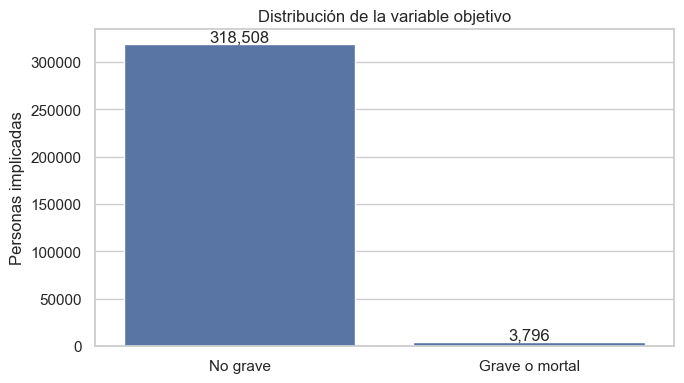

Prevalencia de lesión grave o mortal: 1.18%
Casos con lesividad desconocida: 13


In [9]:
known_target = data.loc[data['lesion_grave'].notna(), 'lesion_grave'].astype(int)
target_counts = known_target.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=['No grave', 'Grave o mortal'], y=target_counts.reindex([0, 1]), ax=ax)
ax.set(title='Distribución de la variable objetivo', xlabel='', ylabel='Personas implicadas')
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
plt.tight_layout()
plt.show()

print(f'Prevalencia de lesión grave o mortal: {known_target.mean():.2%}')
print(f'Casos con lesividad desconocida: {data.lesion_grave.isna().sum():,}')

**NOTA**: Un problema que vamos a tener es que la incidencia de la variable objetivo es muy baja

## 6. Evolución anual inicial

Esta comparación permite comprobar si la prevalencia es estable en el tiempo. Si cambia, reforzará la decisión de reservar 2025 como test temporal en lugar de hacer una partición aleatoria.

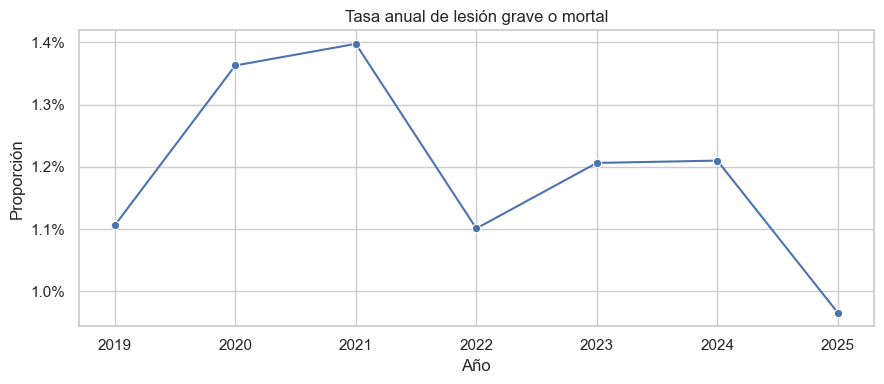

,anio,personas,graves,tasa_grave
0,2019,51809,573,0.01106
1,2020,32430,442,0.013629
2,2021,41783,584,0.013977
3,2022,47051,518,0.011009
4,2023,48826,589,0.012063
5,2024,49338,597,0.0121
6,2025,51067,493,0.009654


In [10]:
annual_target = (
    data.dropna(subset=['lesion_grave'])
        .groupby('anio')
        .agg(personas=('lesion_grave', 'size'), graves=('lesion_grave', 'sum'), tasa_grave=('lesion_grave', 'mean'))
        .reset_index()
)


fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=annual_target, x='anio', y='tasa_grave', marker='o', ax=ax)

ax.set(title='Tasa anual de lesión grave o mortal', xlabel='Año', ylabel='Proporción')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.1%}')

plt.tight_layout()
plt.show()

annual_target

Parece qeu la incidencia es más o menos estable en el tiempo (hay que tener en cuenta que el rango del eje y es pequeño), aunque parece que ha disminuido ligeramente. 

## 7. Próximo paso

Una vez revisados estos resultados, el siguiente notebook realizará el EDA: duplicidad por expediente, ausencia de variables, patrones por persona, vehículo, accidente, distrito y tiempo. Después fijaremos el conjunto exacto de variables disponibles en el momento de la predicción.